# 02 · Vertical Fusion of Elementwise Ops

**Goal:** apply a chain of `k` elementwise multiplies to a large tensor, once as `k` separate GPU kernels (unfused) and once as a single kernel generated by `torch.compile` (fused). Sweeping `k` walks the fused kernel along the roofline, from memory-bound to compute-bound, while the unfused version stays stuck at the same low arithmetic intensity.

Based on the microbenchmark in Horace He's [Making Deep Learning Go Brrrr From First Principles](https://horace.io/brrr_intro.html), with `torch.compile` in place of the deprecated TorchScript `nvFuser`.

**Requirements:** NVIDIA GPU (compute capability ≥ 7.0) + CUDA + PyTorch. On a machine without CUDA the code runs on a small tensor for correctness only.

## 0. Hardware

In [1]:
import torch

GIGA = 1e9
TERA = 1e12

IS_CUDA_AVAILABLE = torch.cuda.is_available()
DEVICE = torch.device("cuda" if IS_CUDA_AVAILABLE else "cpu")

if IS_CUDA_AVAILABLE:
    properties = torch.cuda.get_device_properties(DEVICE)
    print(f"GPU                : {properties.name}")
    print(f"Compute capability : {properties.major}.{properties.minor} (SM{properties.major}{properties.minor})")
    print(f"DRAM               : {properties.total_memory / GIGA:.1f} GB")
else:
    print("No CUDA GPU found: running on CPU for correctness only.")

GPU                : Tesla T4
Compute capability : 7.5 (SM75)
DRAM               : 15.6 GB


## 1. Spec Sheet

Defaults are the **NVIDIA T4**. Edit them for your GPU.

| T4 datasheet | Value |
|---|---|
| Peak FP32 (CUDA cores) | 8.1 TFLOP/s |
| Memory bandwidth | 320 GB/s |

**Why FP32 and not tensor cores?** Tensor cores only do matrix multiplies. An elementwise multiply runs on the regular CUDA cores. We use FP32 because `torch.compile` computes FP16 elementwise ops in FP32 internally anyway.

**Why halve the peak?** The datasheet's 8.1 TFLOP/s assumes every instruction is a fused multiply-add (FMA), counted as 2 FLOPs. Our op is a plain multiply: 1 FLOP per instruction, so the real ceiling is 8.1 / 2 ≈ 4.05 TFLOP/s.

In [2]:
PEAK_FP32_FMA_FLOPS_PER_SECOND = 8.1 * TERA
FLOPS_PER_FMA = 2
PEAK_MULTIPLY_FLOPS_PER_SECOND = PEAK_FP32_FMA_FLOPS_PER_SECOND / FLOPS_PER_FMA
PEAK_MEMORY_BANDWIDTH_BYTES_PER_SECOND = 320 * GIGA
DTYPE = torch.float32

RIDGE_POINT = PEAK_MULTIPLY_FLOPS_PER_SECOND / PEAK_MEMORY_BANDWIDTH_BYTES_PER_SECOND
print(f"Multiply peak: {PEAK_MULTIPLY_FLOPS_PER_SECOND / TERA:.2f} TFLOP/s | Ridge point: {RIDGE_POINT:.1f} FLOP/byte")

Multiply peak: 4.05 TFLOP/s | Ridge point: 12.7 FLOP/byte


## 2. The Operation

Multiply every number in a tensor by 2, `k` times in a row:

```
for _ in range(k):
    x = x * 2
```

The tensor has 2²⁴ ≈ 16.8M numbers, 64 MB in FP32. That's 16× the T4's 4 MB L2 cache, so every read really comes from DRAM.

Values overflow to `inf` after about 128 doublings. That doesn't matter: the GPU multiplies `inf` exactly as fast as any other number.

In [3]:
TENSOR_ELEMENT_COUNT = 2 ** 24 if IS_CUDA_AVAILABLE else 2 ** 16
MULTIPLIER = 2
RANDOM_SEED = 0

torch.manual_seed(RANDOM_SEED)
x = torch.randn(TENSOR_ELEMENT_COUNT, device=DEVICE, dtype=DTYPE)
BYTES_PER_ELEMENT = x.element_size()

print(f"x: {x.numel():,} numbers | {x.numel() * BYTES_PER_ELEMENT / 1e6:.0f} MB | dtype: {DTYPE}")

x: 16,777,216 numbers | 67 MB | dtype: torch.float32


## 3. Unfused vs Fused

**Unfused (plain PyTorch).** Each `x * 2` is its own kernel. Every kernel reads the whole tensor from DRAM and writes the whole result back:

| | Per op | For `k` ops |
|---|---|---|
| FLOPs | `n` | `k·n` |
| Bytes | `2·n·4` (read + write) | `k·2·n·4` |
| Intensity | 1/8 FLOP/byte | **1/8 FLOP/byte, always** |

**Fused (`torch.compile`).** The compiler turns the whole chain into one kernel. Each number is read once, multiplied `k` times while it sits in a register, and written once:

| | For `k` ops |
|---|---|
| FLOPs | `k·n` |
| Bytes | `2·n·4`, constant |
| Intensity | **`k`/8 FLOP/byte** |

Same FLOPs, but the fused version's bytes don't grow with `k`. Its intensity crosses the ridge at `k ≈ 8 × ridge ≈ 100` ops.

In [4]:
OP_COUNT_FOR_CHECK = 8

def multiply_chain(tensor):
    for _ in range(OP_COUNT_FOR_CHECK):
        tensor = tensor * MULTIPLIER
    return tensor

fused_multiply_chain = torch.compile(multiply_chain)

torch.testing.assert_close(fused_multiply_chain(x), multiply_chain(x))
print(f"Fused and unfused match for k = {OP_COUNT_FOR_CHECK} ✓")

Fused and unfused match for k = 8 ✓


**Is it really one kernel?** The profiler lists every GPU kernel launched. Unfused should show `k` kernels; fused should show one (a Triton kernel generated by `torch.compile`).

In [5]:
if IS_CUDA_AVAILABLE:
    for name, chain in {"Unfused": multiply_chain, "Fused": fused_multiply_chain}.items():
        with torch.profiler.profile(activities=[torch.profiler.ProfilerActivity.CUDA]) as profiler:
            chain(x)
            torch.cuda.synchronize()
        kernel_names = [event.name for event in profiler.events() if event.device_type == torch.autograd.DeviceType.CUDA]
        print(f"{name}: {len(kernel_names)} kernel(s) -> {sorted(set(kernel_names))}")
else:
    print("Skipped: needs a CUDA GPU.")

Unfused: 8 kernel(s) -> ['void at::native::vectorized_elementwise_kernel<4, at::native::AUnaryFunctor<float, float, float, at::native::binary_internal::MulFunctor<float> >, std::array<char*, 2ul> >(int, at::native::AUnaryFunctor<float, float, float, at::native::binary_internal::MulFunctor<float> >, std::array<char*, 2ul>)']
Fused: 1 kernel(s) -> ['triton_poi_fused_mul_0']


/usr/local/lib/python3.12/dist-packages/torch/profiler/profiler.py:217: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


## 4. Measuring

For each `k` we build the chain, compile it, and time both versions:
- **Warmup:** the first fused call compiles the kernel (seconds), so warmup absorbs it.
- **Repeats:** each version is timed several times and we keep the **median**, so one slow run doesn't distort the result.
- **CUDA events:** timestamps recorded on the GPU, read after `synchronize()`.
- `torch._dynamo.reset()` clears the compile cache so each `k` gets a fresh kernel.

We also print the GPU clock and temperature before and after. The T4 lowers its clock when it gets hot, which shows up as lower FLOP/s.

In [6]:
import statistics
import subprocess
import time

OP_COUNT_SWEEP = [2 ** exponent for exponent in range(10)]
WARMUP_ITERATIONS = 3
TIMING_ITERATIONS = 20 if IS_CUDA_AVAILABLE else 1
TIMING_REPEATS = 5 if IS_CUDA_AVAILABLE else 1
MILLISECONDS_PER_SECOND = 1e3
GPU_STATUS_COMMAND = ["nvidia-smi", "--query-gpu=clocks.sm,clocks.max.sm,temperature.gpu,power.draw", "--format=csv"]

if IS_CUDA_AVAILABLE:
    print("Before:\n" + subprocess.run(GPU_STATUS_COMMAND, capture_output=True, text=True).stdout)

seconds_per_call = {"Unfused": [], "Fused": []}

for op_count in OP_COUNT_SWEEP:
    def multiply_chain(tensor):
        for _ in range(op_count):
            tensor = tensor * MULTIPLIER
        return tensor

    torch._dynamo.reset()
    chains = {"Unfused": multiply_chain, "Fused": torch.compile(multiply_chain)}

    for name, chain in chains.items():
        for _ in range(WARMUP_ITERATIONS):
            chain(x)

        repeat_seconds = []
        for _ in range(TIMING_REPEATS):
            if IS_CUDA_AVAILABLE:
                start_event = torch.cuda.Event(enable_timing=True)
                end_event = torch.cuda.Event(enable_timing=True)
                torch.cuda.synchronize()
                start_event.record()
                for _ in range(TIMING_ITERATIONS):
                    chain(x)
                end_event.record()
                torch.cuda.synchronize()
                elapsed_seconds = start_event.elapsed_time(end_event) / MILLISECONDS_PER_SECOND
            else:
                start_time = time.perf_counter()
                for _ in range(TIMING_ITERATIONS):
                    chain(x)
                elapsed_seconds = time.perf_counter() - start_time
            repeat_seconds.append(elapsed_seconds / TIMING_ITERATIONS)

        seconds_per_call[name].append(statistics.median(repeat_seconds))

if IS_CUDA_AVAILABLE:
    print("After:\n" + subprocess.run(GPU_STATUS_COMMAND, capture_output=True, text=True).stdout)
print(f"Timed {len(OP_COUNT_SWEEP)} op counts x 2 versions")

Before:
clocks.current.sm [MHz], clocks.max.sm [MHz], temperature.gpu, power.draw [W]
585 MHz, 1590 MHz, 61, 35.53 W
300 MHz, 1590 MHz, 55, 10.72 W

After:
clocks.current.sm [MHz], clocks.max.sm [MHz], temperature.gpu, power.draw [W]
1485 MHz, 1590 MHz, 76, 66.29 W
300 MHz, 1590 MHz, 48, 10.52 W

Timed 10 op counts x 2 versions


In [7]:
MICROSECONDS_PER_SECOND = 1e6

flops_sweep = [op_count * TENSOR_ELEMENT_COUNT for op_count in OP_COUNT_SWEEP]
bytes_sweep = {
    "Unfused": [op_count * 2 * TENSOR_ELEMENT_COUNT * BYTES_PER_ELEMENT for op_count in OP_COUNT_SWEEP],
    "Fused": [2 * TENSOR_ELEMENT_COUNT * BYTES_PER_ELEMENT for _ in OP_COUNT_SWEEP],
}
intensity_sweep = {name: [flops / bytes for flops, bytes in zip(flops_sweep, bytes_sweep[name])] for name in bytes_sweep}
achieved_flops_per_second = {name: [flops / seconds for flops, seconds in zip(flops_sweep, seconds_per_call[name])] for name in seconds_per_call}
achieved_bytes_per_second = {name: [bytes / seconds for bytes, seconds in zip(bytes_sweep[name], seconds_per_call[name])] for name in seconds_per_call}

print(f"{'k':>4} | {'unfused us':>10} {'TFLOP/s':>8} {'GB/s':>6} | {'fused us':>9} {'FLOP/B':>7} {'TFLOP/s':>8} {'GB/s':>6} | {'speedup':>7}")
for index, op_count in enumerate(OP_COUNT_SWEEP):
    unfused_seconds = seconds_per_call["Unfused"][index]
    fused_seconds = seconds_per_call["Fused"][index]
    print(f"{op_count:4d} | "
          f"{unfused_seconds * MICROSECONDS_PER_SECOND:10.1f} {achieved_flops_per_second['Unfused'][index] / TERA:8.3f} {achieved_bytes_per_second['Unfused'][index] / GIGA:6.0f} | "
          f"{fused_seconds * MICROSECONDS_PER_SECOND:9.1f} {intensity_sweep['Fused'][index]:7.2f} {achieved_flops_per_second['Fused'][index] / TERA:8.3f} {achieved_bytes_per_second['Fused'][index] / GIGA:6.0f} | "
          f"{unfused_seconds / fused_seconds:6.1f}x")

   k | unfused us  TFLOP/s   GB/s |  fused us  FLOP/B  TFLOP/s   GB/s | speedup
   1 |      566.6    0.030    237 |     538.5    0.12    0.031    249 |    1.1x
   2 |     1129.6    0.030    238 |     547.4    0.25    0.061    245 |    2.1x
   4 |     2318.9    0.029    232 |     553.7    0.50    0.121    242 |    4.2x
   8 |     4628.8    0.029    232 |     557.3    1.00    0.241    241 |    8.3x
  16 |     9249.1    0.029    232 |     551.0    2.00    0.487    244 |   16.8x
  32 |    18477.8    0.029    232 |     550.0    4.00    0.976    244 |   33.6x
  64 |    36910.3    0.029    233 |     610.6    8.00    1.759    220 |   60.4x
 128 |    73666.5    0.029    233 |     897.8   16.00    2.392    150 |   82.1x
 256 |   147520.9    0.029    233 |    1525.2   32.00    2.816     88 |   96.7x
 512 |   294386.3    0.029    233 |    2764.4   64.00    3.107     49 |  106.5x


## 5. Plots

- **Runtime vs `k`:** unfused grows linearly (every op is another full trip to DRAM); fused stays flat while memory-bound, then rises once compute becomes the limit.
- **Achieved TFLOP/s vs `k`**, against the multiply peak.
- **Roofline:** all unfused points sit at the same intensity (1/8); the fused points walk right along the slanted line and flatten at the ridge.

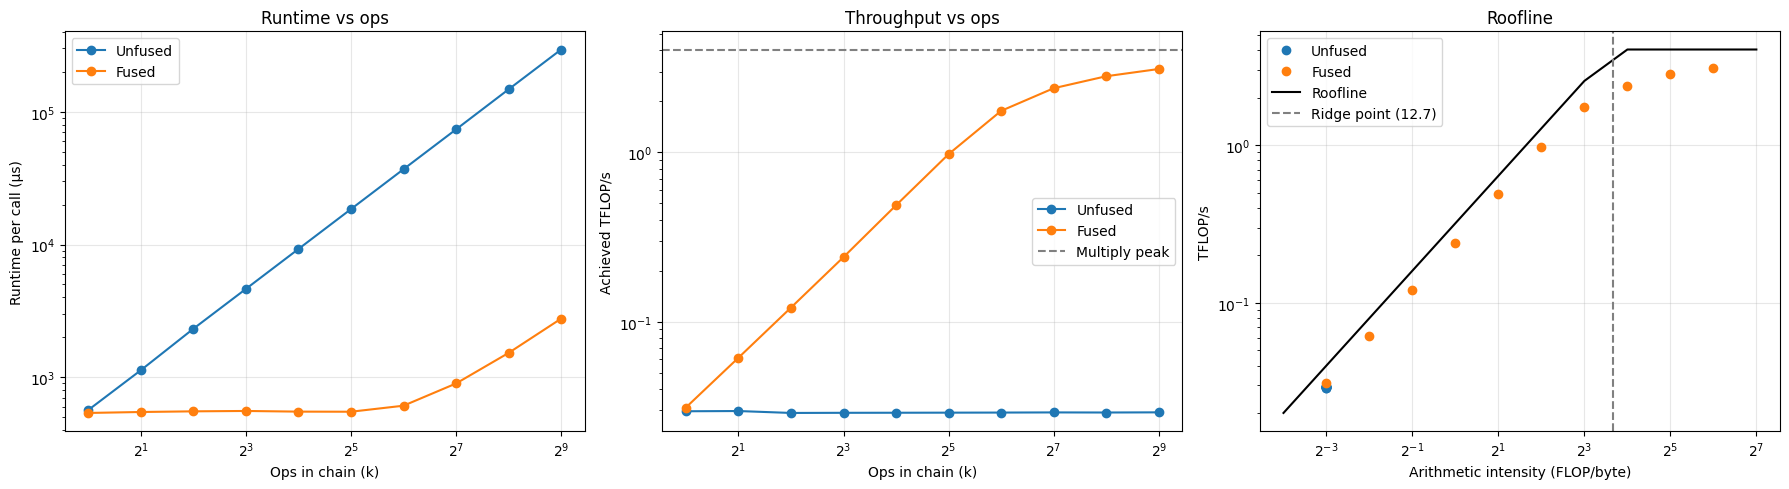

In [8]:
import matplotlib.pyplot as plt

roofline_intensities = [2 ** exponent for exponent in range(-4, 8)]
roofline_ceiling = [min(PEAK_MULTIPLY_FLOPS_PER_SECOND, intensity * PEAK_MEMORY_BANDWIDTH_BYTES_PER_SECOND) / TERA
                    for intensity in roofline_intensities]

figure, (runtime_axis, throughput_axis, roofline_axis) = plt.subplots(1, 3, figsize=(18, 5))

for name in seconds_per_call:
    runtime_axis.plot(OP_COUNT_SWEEP, [seconds * MICROSECONDS_PER_SECOND for seconds in seconds_per_call[name]], "o-", label=name)
    throughput_axis.plot(OP_COUNT_SWEEP, [flops / TERA for flops in achieved_flops_per_second[name]], "o-", label=name)
    roofline_axis.plot(intensity_sweep[name], [flops / TERA for flops in achieved_flops_per_second[name]], "o", label=name)

runtime_axis.set_ylabel("Runtime per call (µs)")
runtime_axis.set_title("Runtime vs ops")
throughput_axis.axhline(PEAK_MULTIPLY_FLOPS_PER_SECOND / TERA, color="gray", linestyle="--", label="Multiply peak")
throughput_axis.set_ylabel("Achieved TFLOP/s")
throughput_axis.set_title("Throughput vs ops")
for axis in (runtime_axis, throughput_axis):
    axis.set_xlabel("Ops in chain (k)")

roofline_axis.plot(roofline_intensities, roofline_ceiling, "k-", label="Roofline")
roofline_axis.axvline(RIDGE_POINT, color="gray", linestyle="--", label=f"Ridge point ({RIDGE_POINT:.1f})")
roofline_axis.set_xlabel("Arithmetic intensity (FLOP/byte)")
roofline_axis.set_ylabel("TFLOP/s")
roofline_axis.set_title("Roofline")

for axis in (runtime_axis, throughput_axis, roofline_axis):
    axis.set_xscale("log", base=2)
    axis.set_yscale("log")
    axis.legend()
    axis.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**What to look for (on the GPU)**

- **Fused, `k` up to ~64:** runtime flat at roughly the time to move 128 MB (≈ 0.4 ms at 320 GB/s). The extra multiplies are free, hidden behind memory traffic.
- **Fused, `k` past ~100:** runtime starts climbing. The kernel has crossed the ridge and is now compute-bound.
- **Unfused:** runtime doubles with every doubling of `k`, and TFLOP/s never moves, because intensity is stuck at 1/8.
- **Speedup ≈ `k`** while fused is memory-bound, because unfused moves `k` times the bytes.